# 02 Data Preparation

This notebook reproduces the data preparation workflow originally performed in SAS Viya using Python.

The objective is to transform the raw customer churn dataset into a clean, modelling-ready dataset by addressing data leakage, placeholder values, categorical grouping, skewed variables, and exporting a processed dataset for later machine learning.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load Raw Dataset

The raw dataset is loaded from the `data/raw/` directory.

In [3]:
DATA_PATH = "../data/raw/BankChurners.csv"

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()

Rows: 10,127
Columns: 23


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 3. Remove Data Leakage Variables

The original Kaggle dataset includes two `Naive_Bayes_Classifier` columns. These columns are model-generated prediction probabilities from a previous classifier.

Including these variables in a new model would introduce data leakage and artificially inflate predictive performance. Therefore, they are removed before any data preparation or modelling.

In [4]:
leakage_cols = [
    col for col in df.columns
    if col.startswith("Naive_Bayes_Classifier")
]

leakage_cols

['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

In [5]:
df = df.drop(columns=leakage_cols)

print(f"Shape after removing leakage variables: {df.shape}")

Shape after removing leakage variables: (10127, 21)


## 4. Create Binary Target Variable

The original target variable is `Attrition_Flag`.

For modelling, it is converted into a binary `Churn` variable:

- `Existing Customer` → `0`
- `Attrited Customer` → `1`

In [6]:
df["Churn"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

df[["Attrition_Flag", "Churn"]].head()

,Attrition_Flag,Churn
0,Existing Customer,0
1,Existing Customer,0
2,Existing Customer,0
3,Existing Customer,0
4,Existing Customer,0


## 5. Data Preparation Strategy

The data preparation workflow mirrors the original SAS Viya process while using open-source Python tools.

The main preparation steps are:

1. Remove leakage variables
2. Create a binary churn target
3. Inspect placeholder missing values
4. Consolidate categorical variables
5. Assess skewness in numerical variables
6. Apply log transformations to skewed variables
7. Validate the prepared dataset
8. Export the processed dataset

## 6. Placeholder Missing Value Assessment

Although the dataset contains no technical missing values, several categorical variables contain `"Unknown"` values.

These values represent incomplete customer information and require explicit handling before modelling.

In [7]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

unknown_counts = {}

for col in categorical_cols:
    unknown_count = (df[col] == "Unknown").sum()
    if unknown_count > 0:
        unknown_counts[col] = unknown_count

unknown_summary = (
    pd.DataFrame.from_dict(
        unknown_counts,
        orient="index",
        columns=["Unknown Count"]
    )
    .reset_index()
    .rename(columns={"index": "Variable"})
)

unknown_summary["Unknown (%)"] = (
    unknown_summary["Unknown Count"] / len(df) * 100
).round(2)

unknown_summary.sort_values("Unknown (%)", ascending=False)

,Variable,Unknown Count,Unknown (%)
0,Education_Level,1519,15.00
2,Income_Category,1112,10.98
1,Marital_Status,749,7.40


### Placeholder Missing Value Treatment Strategy

The `"Unknown"` categories are retained instead of being removed.

This decision is made because `"Unknown"` may represent meaningful missingness in customer profile information. Removing these records would reduce the dataset size and may introduce bias.

For modelling, the affected variables will be handled through categorical grouping and encoding.

## 7. Categorical Variable Consolidation

The SAS Viya workflow consolidated selected categorical variables into broader business categories to improve interpretability and reduce category sparsity during modelling.

In Python, equivalent grouping rules are applied to:

- `Education_Level`
- `Income_Category`

The original variables are preserved, while grouped versions are created for modelling.

In [10]:
education_mapping = {
    "Uneducated": "Low Education",
    "High School": "Low Education",
    "College": "Medium Education",
    "Graduate": "Medium Education",
    "Post-Graduate": "High Education",
    "Doctorate": "High Education",
    "Unknown": "Unknown"
}

income_mapping = {
    "Less than $40K": "Low Income",
    "$40K - $60K": "Low Income",
    "$60K - $80K": "Middle Income",
    "$80K - $120K": "Middle Income",
    "$120K +": "High Income",
    "Unknown": "Unknown"
}

df["Education_Group"] = df["Education_Level"].map(education_mapping)
df["Income_Group"] = df["Income_Category"].map(income_mapping)

df[[
    "Education_Level",
    "Education_Group",
    "Income_Category",
    "Income_Group"
]].head()

,Education_Level,Education_Group,Income_Category,Income_Group
0,High School,Low Education,$60K - $80K,Middle Income
1,Graduate,Medium Education,Less than $40K,Low Income
2,Graduate,Medium Education,$80K - $120K,Middle Income
3,High School,Low Education,Less than $40K,Low Income
4,Uneducated,Low Education,$60K - $80K,Middle Income


In [29]:
education_order = [
    "Low Education",
    "Medium Education",
    "High Education",
    "Unknown"
]

income_order = [
    "Low Income",
    "Middle Income",
    "High Income",
    "Unknown"
]

education_distribution = (
    df["Education_Group"]
    .value_counts()
    .reindex(education_order)
)

income_distribution = (
    df["Income_Group"]
    .value_counts()
    .reindex(income_order)
)

print("Education Group Distribution")
display(education_distribution)

print("\nIncome Group Distribution")
display(income_distribution)

Education Group Distribution


Education_Group
Low Education       3500
Medium Education    4141
High Education       967
Unknown             1519
Name: count, dtype: int64


Income Group Distribution


Income_Group
Low Income       5351
Middle Income    2937
High Income       727
Unknown          1112
Name: count, dtype: int64

### Categorical Grouping Findings

The grouped variables reduce category sparsity while preserving meaningful customer segments.

- Education levels are grouped into low, medium, high, and unknown categories.
- Income categories are grouped into low, middle, high, and unknown categories.

This improves interpretability and reduces unnecessary categorical fragmentation during modelling.

## 8. Skewness Assessment

The SAS Viya report identified several positively skewed numerical variables, especially credit and utilization-related fields.

This section calculates skewness to determine which variables may benefit from logarithmic transformation.

In [12]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Exclude identifier and target from skewness assessment
numeric_features_for_skewness = [
    col for col in numeric_cols
    if col not in ["CLIENTNUM", "Churn"]
]

skewness_summary = (
    df[numeric_features_for_skewness]
    .skew()
    .reset_index()
    .rename(columns={"index": "Variable", 0: "Skewness"})
)

skewness_summary["Absolute Skewness"] = skewness_summary["Skewness"].abs()

skewness_summary.sort_values("Absolute Skewness", ascending=False)

,Variable,Skewness,Absolute Skewness
12,Total_Ct_Chng_Q4_Q1,2.064031,2.064031
10,Total_Trans_Amt,2.041003,2.041003
9,Total_Amt_Chng_Q4_Q1,1.732063,1.732063
6,Credit_Limit,1.666726,1.666726
8,Avg_Open_To_Buy,1.661697,1.661697
13,Avg_Utilization_Ratio,0.718008,0.718008
4,Months_Inactive_12_mon,0.633061,0.633061
3,Total_Relationship_Count,-0.162452,0.162452
11,Total_Trans_Ct,0.153673,0.153673
7,Total_Revolving_Bal,-0.148837,0.148837


### Variables Selected for Log Transformation

To reproduce the original SAS Viya preprocessing workflow, logarithmic transformation was applied to the following credit-related variables:

- Credit_Limit
- Avg_Open_To_Buy
- Avg_Utilization_Ratio

These variables represent continuous financial measures with positively skewed distributions. The transformation uses `log1p(x)`, which is equivalent to `log(x + 1)` and safely handles zero values.

In [13]:
log_transform_cols = [
    "Credit_Limit",
    "Avg_Open_To_Buy",
    "Avg_Utilization_Ratio"
]

for col in log_transform_cols:
    df[f"LOG_{col}"] = np.log1p(df[col])

df[[col for col in df.columns if col.startswith("LOG_")]].head()

,LOG_Credit_Limit,LOG_Avg_Open_To_Buy,LOG_Avg_Utilization_Ratio
0,9.448727,9.385553,0.059212
1,9.018817,8.908289,0.099845
2,8.137103,8.137103,0.000000
3,8.105911,6.680855,0.565314
4,8.458928,8.458928,0.000000


## 9. Skewness Before and After Transformation

This section compares skewness before and after logarithmic transformation to verify whether the transformation reduced distributional skewness.

In [14]:
skewness_comparison = []

for col in log_transform_cols:
    original_skew = df[col].skew()
    transformed_skew = df[f"LOG_{col}"].skew()

    skewness_comparison.append({
        "Variable": col,
        "Original Skewness": round(original_skew, 4),
        "Log Transformed Skewness": round(transformed_skew, 4),
        "Absolute Reduction": round(abs(original_skew) - abs(transformed_skew), 4)
    })

skewness_comparison_df = pd.DataFrame(skewness_comparison)

skewness_comparison_df

,Variable,Original Skewness,Log Transformed Skewness,Absolute Reduction
0,Credit_Limit,1.6667,0.4573,1.2094
1,Avg_Open_To_Buy,1.6617,-0.0953,1.5664
2,Avg_Utilization_Ratio,0.7180,0.5213,0.1967


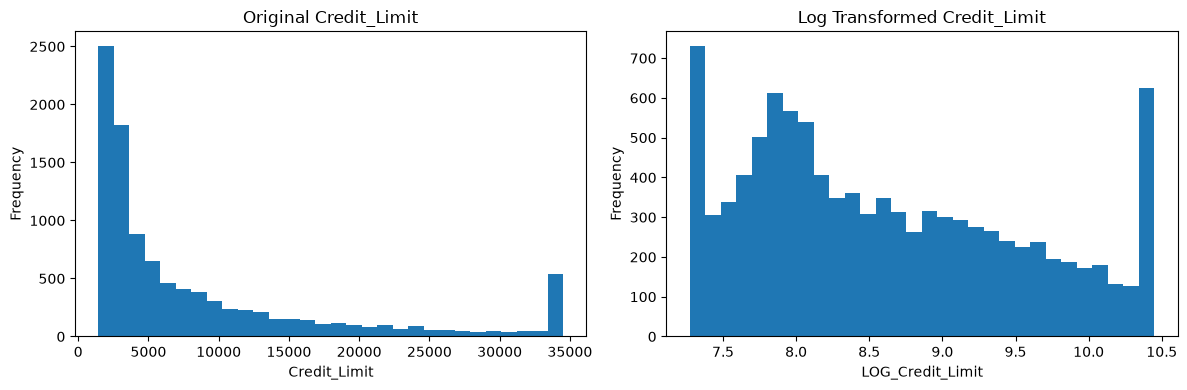

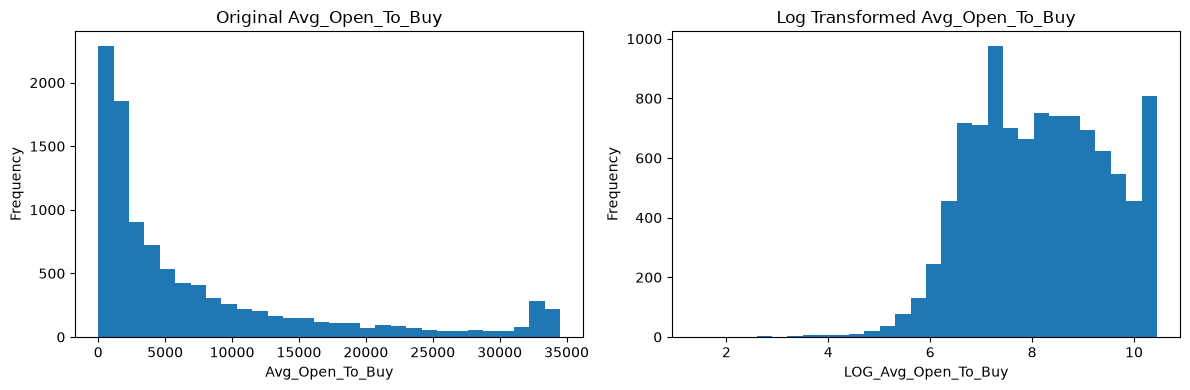

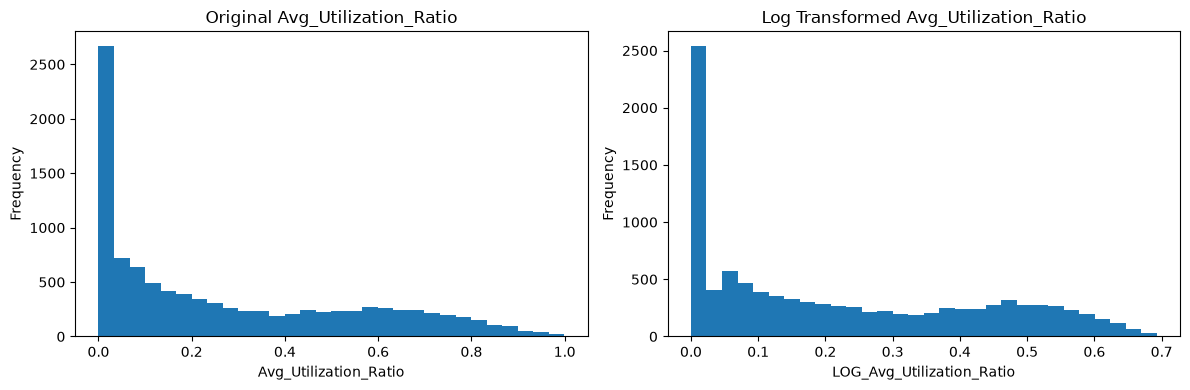

In [15]:
for col in log_transform_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df[col], bins=30)
    axes[0].set_title(f"Original {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    axes[1].hist(df[f"LOG_{col}"], bins=30)
    axes[1].set_title(f"Log Transformed {col}")
    axes[1].set_xlabel(f"LOG_{col}")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

### Skewness Transformation Findings

The log transformation reduces the influence of extreme values in selected credit and utilization variables, resulting in more stable feature distributions for downstream modelling while preserving the original variables for comparison and interpretability.

Although several numerical variables exhibited positive skewness, logarithmic transformation was applied only to `Credit_Limit`, `Avg_Open_To_Buy`, and `Avg_Utilization_Ratio`. These continuous financial variables exhibit long right-tailed distributions and were transformed to reproduce the original SAS Viya preprocessing workflow. Transaction-related variables were retained in their original scale to preserve business interpretability, while the tree-based models used later in the analysis are generally robust to skewed predictor distributions.

## 10. Constructing the Processed Dataset

This section defines the variables that will be retained in the processed modelling dataset.

The processed dataset excludes:

- `CLIENTNUM`, because it is an identifier
- `Attrition_Flag`, because `Churn` is the binary modelling target
- Leakage variables, which were already removed

The processed dataset retains:

- numerical customer behaviour variables
- categorical customer profile variables
- grouped education and income variables
- log-transformed credit and utilization variables
- binary churn target

In [16]:
drop_cols = [
    "CLIENTNUM",
    "Attrition_Flag"
]

processed_df = df.drop(columns=drop_cols)

processed_df.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn,Education_Group,Income_Group,LOG_Credit_Limit,LOG_Avg_Open_To_Buy,LOG_Avg_Utilization_Ratio
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0,Low Education,Middle Income,9.448727,9.385553,0.059212
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0,Medium Education,Low Income,9.018817,8.908289,0.099845
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0,Medium Education,Middle Income,8.137103,8.137103,0.000000
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0,Low Education,Low Income,8.105911,6.680855,0.565314
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0,Low Education,Middle Income,8.458928,8.458928,0.000000


## 11. Processed Dataset Validation

Before exporting the processed dataset, several validation checks are performed.

In [17]:
validation_summary = pd.DataFrame({
    "Check": [
        "Rows",
        "Columns",
        "Technical Missing Values",
        "Duplicate Rows",
        "Target Column Present",
        "Identifier Removed",
        "Leakage Variables Removed"
    ],
    "Result": [
        processed_df.shape[0],
        processed_df.shape[1],
        processed_df.isna().sum().sum(),
        processed_df.duplicated().sum(),
        "Churn" in processed_df.columns,
        "CLIENTNUM" not in processed_df.columns,
        not any(col.startswith("Naive_Bayes_Classifier") for col in processed_df.columns)
    ]
})

validation_summary

,Check,Result
0,Rows,10127
1,Columns,25
2,Technical Missing Values,0
3,Duplicate Rows,0
4,Target Column Present,True
5,Identifier Removed,True
6,Leakage Variables Removed,True


In [18]:
processed_df.dtypes.value_counts().rename_axis("Data Type").reset_index(name="Count")

,Data Type,Count
0,int64,10
1,float64,8
2,str,7


### Validation Findings

The processed dataset is structurally valid for downstream modelling.

It contains no technical missing values, excludes identifier and leakage variables, and includes the binary `Churn` target required for classification.

## 12. Export Processed Dataset

The final processed dataset is exported to the `data/processed/` directory for use in later modelling notebooks.

In [24]:
OUTPUT_PATH = "../data/processed/customer_churn_processed.csv"

processed_df.to_csv(OUTPUT_PATH, index=False)

print(f"Processed dataset exported to: {OUTPUT_PATH}")
print(f"Processed dataset shape: {processed_df.shape}")
processed_df.info()

Processed dataset exported to: ../data/processed/customer_churn_processed.csv
Processed dataset shape: (10127, 25)
<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_Age               10127 non-null  int64  
 1   Gender                     10127 non-null  str    
 2   Dependent_count            10127 non-null  int64  
 3   Education_Level            10127 non-null  str    
 4   Marital_Status             10127 non-null  str    
 5   Income_Category            10127 non-null  str    
 6   Card_Category              10127 non-null  str    
 7   Months_on_book             10127 non-null  int64  
 8   Total_Relationship_Count   10127 non-null  int64  
 9   Months_Inactive_12_mon     10127 non-null  int64  
 10  Contacts_Count_12_mon      10127 non-null  int64  
 11  Credit_Limit               10127 non-null  float64
 12

## 13. Data Preparation Summary

This notebook reproduced the main data preparation steps from the SAS Viya workflow using Python.

Key preparation steps completed:

- Removed two Naive Bayes leakage variables
- Created binary churn target
- Identified placeholder `"Unknown"` values
- Retained `"Unknown"` categories as meaningful missingness
- Created grouped education and income variables
- Assessed skewness in numerical variables
- Applied log transformations to selected skewed variables
- Validated the processed dataset
- Exported the modelling-ready dataset

The processed dataset is now ready for feature engineering and predictive modelling. The next notebook will use the processed dataset to train and compare customer churn prediction models.